# Chapter 4: Multi-Knob Attribution & Multiple Regression

Agent harnesses expose multiple continuous configuration knobs that interact non-linearly:
1. `thinking_budget` ($T \in [100, 4000]$ tokens): improves complex planning initially, but exhibits **quadratic decay** at high budgets due to overthinking / reasoning loops.
2. `context_chunks` ($C \in [1, 20]$ retrieved RAG chunks): increases recall initially, then degrades due to **context distraction** ("lost in the middle").
3. `tool_timeout` ($S \in [5, 60]$ seconds): prevents premature RPC cancellations.

---

## 1. Second-Order Response Surface Model

Rather than tuning one knob at a time (which misses interaction synergies), we fit a **Second-Order Polynomial Response Surface** via Ordinary Least Squares (`statsmodels` Formula API):
$$\text{PassRate} = \beta_0 + \beta_T T + \beta_{T^2} T^2 + \beta_C C + \beta_{C^2} C^2 + \beta_{TC} (T \cdot C) + \beta_S S + \epsilon$$

To find the analytical stationary point $(T^*, C^*)$, we set the partial derivatives to zero:
$$\frac{\partial \widehat{\text{PassRate}}}{\partial T} = \beta_T + 2\beta_{T^2} T + \beta_{TC} C = 0, \qquad \frac{\partial \widehat{\text{PassRate}}}{\partial C} = \beta_C + 2\beta_{C^2} C + \beta_{TC} T = 0$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from agent_stats.ch04_multi_knob_regression import (
    extract_developer_insights,
    fit_response_surface_model,
    generate_multi_knob_dataset,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120

df_knobs = generate_multi_knob_dataset(n_samples=300, random_state=42)
model = fit_response_surface_model(df_knobs)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              pass_rate   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     1396.
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          3.27e-212
Time:                        22:59:06   Log-Likelihood:                 731.20
No. Observations:                 300   AIC:                            -1448.
Df Residuals:                     293   BIC:                            -1422.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

## 2. 3D Response Surface & 2D Iso-Performance Contour Map

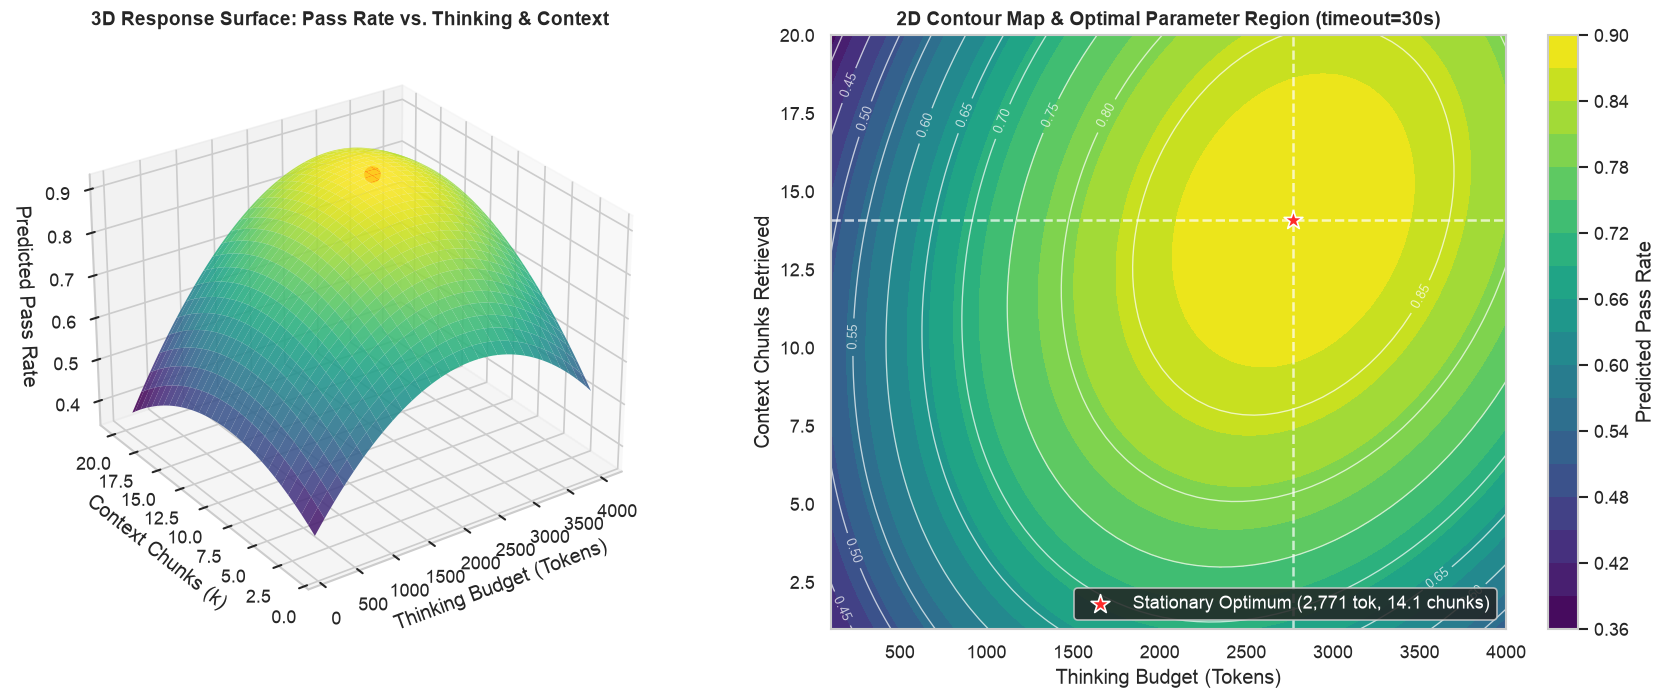

In [2]:
insights = extract_developer_insights(model)
opt_t = insights["optimal_thinking_budget"]
opt_c = insights["optimal_context_chunks"]

t_grid = np.linspace(100, 4000, 60)
c_grid = np.linspace(1, 20, 60)
tt, cc = np.meshgrid(t_grid, c_grid)
grid_df = pd.DataFrame({
    "thinking_budget": tt.ravel(),
    "context_chunks": cc.ravel(),
    "tool_timeout": np.full(tt.size, 30.0),
})
zz = model.predict(grid_df).to_numpy().reshape(tt.shape)

fig = plt.figure(figsize=(15, 6.0))

# Subplot 1: 3D Response Surface
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
surf = ax1.plot_surface(tt, cc, zz, cmap="viridis", alpha=0.88, edgecolor="none")
ax1.scatter([opt_t], [opt_c], [ np.max(zz) ], color="red", s=80, label="Global Optimum")
ax1.set_title("3D Response Surface: Pass Rate vs. Thinking & Context", fontsize=11.5, fontweight="bold")
ax1.set_xlabel("Thinking Budget (Tokens)")
ax1.set_ylabel("Context Chunks (k)")
ax1.set_zlabel("Predicted Pass Rate")
ax1.view_init(elev=28, azim=-125)

# Subplot 2: 2D Contour Map with Stationary Optimum & Overthinking Zone
ax2 = fig.add_subplot(1, 2, 2)
cntr = ax2.contourf(tt, cc, zz, levels=18, cmap="viridis")
cs = ax2.contour(tt, cc, zz, levels=10, colors="white", linewidths=0.8, alpha=0.7)
ax2.clabel(cs, inline=True, fontsize=8, fmt="%.2f")
plt.colorbar(cntr, ax=ax2, label="Predicted Pass Rate")

ax2.scatter([opt_t], [opt_c], color="#ff2a2a", edgecolor="white", s=140, zorder=5, marker="*", label=f"Stationary Optimum ({opt_t:,.0f} tok, {opt_c:.1f} chunks)")
ax2.axvline(opt_t, color="white", linestyle="--", alpha=0.7)
ax2.axhline(opt_c, color="white", linestyle="--", alpha=0.7)
ax2.set_title("2D Contour Map & Optimal Parameter Region (timeout=30s)", fontsize=11.5, fontweight="bold")
ax2.set_xlabel("Thinking Budget (Tokens)")
ax2.set_ylabel("Context Chunks Retrieved")
ax2.legend(loc="lower right", facecolor="#222222", labelcolor="white", framealpha=0.85)

plt.tight_layout()
plt.savefig("figures/ch04_multi_knob_response_surface.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Automated Developer Interpretation Exercises

In [3]:
print("=== AUTOMATED DEVELOPER REGRESSION INSIGHTS ===")
for line in insights["plain_english_insights"]:
    print(line)

=== AUTOMATED DEVELOPER REGRESSION INSIGHTS ===
1. Optimal Thinking Budget (at 10 context chunks): ~2,621 tokens (Global joint optimum: 2,771 tokens, 14.1 chunks).
2. Overthinking Penalty: Increasing thinking_budget beyond 2,621 up to 4,000 tokens reduces pass rate by 10.86 percentage points (an average efficiency loss of 0.79% per 100 extra tokens; instantaneous slope at 3,500 tokens is -1.00% per 100 tokens).
3. Context-Thinking Synergy: The interaction term (p = 8.38e-56) shows each additional context chunk adds +0.42 pp more value per 1,000 thinking tokens.
4. Tool Timeout Effect: Each +10s of tool_timeout yields +0.78 pp (p = 4.84e-21), a minor linear effect compared to reasoning & retrieval tuning.
